# **Project: 멋진 챗봇 만들기**

### **라이브러리 버전 확인**

In [1]:
import numpy as np
import pandas as pd
import torch
import nltk
import gensim

print(np.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

1.26.4
3.0.0
2.10.0+cu128
3.9.2
4.4.0


## **Step 1. 데이터 다운로드 및 변수 저장**

In [2]:
import os

# 현재 작업 디렉토리 확인 (Current Working Directory)
BASE_DIR = os.getcwd() + "/data"
FILE_NAME = "ChatbotData.csv"
RAW_PATH = os.path.join(BASE_DIR, FILE_NAME)

print("Raw Data Path :", RAW_PATH)

rawDF = pd.read_csv(RAW_PATH)
rawDF = rawDF.rename(columns={'Q': 'question', 'A': 'answer'})

display(rawDF)

Raw Data Path : /home/jjeong3150/work/transformer_chatbot/data/ChatbotData.csv


,question,answer,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


## **Step 2. 데이터 정제**

In [3]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r"[^a-z0-9가-힣\.\?\!\,\:\s]", "", sentence)
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    return sentence

## **Step3. 데이터 토큰화**

In [4]:
def tokenizer(sentence):
    from konlpy.tag import Mecab
    
    # MeCab 객체 생성
    mecab = Mecab()

    morph_sentence = mecab.morphs(sentence)
            
    return morph_sentence

In [5]:
# 독립된 Dataframe 복사본 생성
prepDF = rawDF.copy()

# 데이터 정제
prepDF['prep_q'] = prepDF['question'].apply(preprocess_sentence)
prepDF['prep_a'] = prepDF['answer'].apply(preprocess_sentence)

# 데이터 토큰화
prepDF['tok_q'] = prepDF['prep_q'].apply(tokenizer)
prepDF['tok_a'] = prepDF['prep_a'].apply(tokenizer)

# 중복 제거
prepDF = prepDF.drop_duplicates(subset=['question', 'answer'])

# 데이터 개수
print(len(prepDF))
display(prepDF)

11750


,question,answer,label,prep_q,prep_a,tok_q,tok_a
0,12시 땡!,하루가 또 가네요.,0,12시 땡!,하루가 또 가네요.,"[12, 시, 땡, !]","[하루, 가, 또, 가, 네요, .]"
1,1지망 학교 떨어졌어,위로해 드립니다.,0,1지망 학교 떨어졌어,위로해 드립니다.,"[1, 지망, 학교, 떨어졌, 어]","[위로, 해, 드립니다, .]"
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,"[3, 박, 4, 일, 놀, 러, 가, 고, 싶, 다]","[여행, 은, 언제나, 좋, 죠, .]"
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,"[3, 박, 4, 일, 정도, 놀, 러, 가, 고, 싶, 다]","[여행, 은, 언제나, 좋, 죠, .]"
4,PPL 심하네,눈살이 찌푸려지죠.,0,ppl 심하네,눈살이 찌푸려지죠.,"[ppl, 심하, 네]","[눈살, 이, 찌푸려, 지, 죠, .]"
...,...,...,...,...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,"[훔쳐, 보, 는, 것, 도, 눈치, 보임, .]","[티, 가, 나, 니까, 눈치, 가, 보이, 는, 거, 죠, !]"
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,"[훔쳐, 보, 는, 것, 도, 눈치, 보임, .]","[훔쳐, 보, 는, 거, 티나, 나, 봐요, .]"
11820,흑기사 해주는 짝남.,설렜겠어요.,2,흑기사 해주는 짝남.,설렜겠어요.,"[흑기사, 해, 주, 는, 짝, 남, .]","[설렜, 겠, 어요, .]"
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,"[힘든, 연애, 좋, 은, 연애, 라는, 게, 무슨, 차이, 일까, ?]","[잘, 헤어질, 수, 있, 는, 사이, 여부, 인, 거, 같, 아요, .]"


In [6]:
# 1. 데이터를 무작위로 섞음 (frac=1은 전체를 다 가져온다는 뜻)
shuffledDF = prepDF.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. 80% 지점 인덱스 계산
split_idx = int(len(shuffledDF) * 0.8)

# 3. 슬라이싱으로 나누기
trainDF = shuffledDF.iloc[:split_idx]
valDF = shuffledDF.iloc[split_idx:]

### **길이 제한 설정**

In [7]:
questions = list(trainDF.tok_q)
answers = list(trainDF.tok_a)

In [8]:
def counter_freq(sentences):
    from collections import Counter
    
    token_list = []
    
    for s in sentences:
        token_list.append(len(s))
    
    token_counter = Counter(token_list)

    return token_counter

In [9]:
counter_q = counter_freq(questions)
counter_a = counter_freq(answers)

In [10]:
import numpy as np

def calc_stats_from_freq(freq_dict):
    values = np.array(list(freq_dict.keys()), dtype=float)
    counts = np.array(list(freq_dict.values()), dtype=float)

    total = counts.sum()

    mean = np.average(values, weights=counts)

    variance = np.average((values - mean) ** 2, weights=counts)
    std = np.sqrt(variance)

    return mean, std, int(total)


In [11]:
import matplotlib.pyplot as plt

def plot_counter(counter, title="Length Distribution"):

    lengths = sorted(counter.keys())
    counts = [counter[l] for l in lengths]

    plt.figure()
    plt.bar(lengths, counts)
    plt.xlabel("Sentence Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

평균: 7.020744680851064
표준편차: 3.492559793838258
전체 개수: 9400
max_len: 16


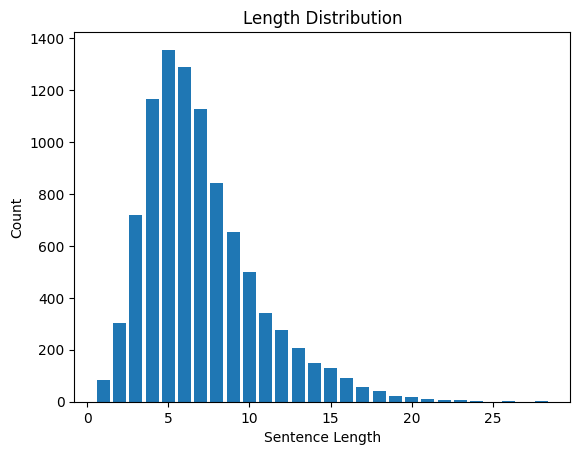

In [12]:
import math

mean, std, total = calc_stats_from_freq(counter_q)
print(f"평균: {mean}")
print(f"표준편차: {std}")
print(f"전체 개수: {total}")

k = 2.5
max_len = math.ceil( mean + k * std )
print(f"max_len: {max_len}")

plot_counter(counter_q)

평균: 8.379255319148935
표준편차: 3.5715923319824676
전체 개수: 9400
max_len: 18


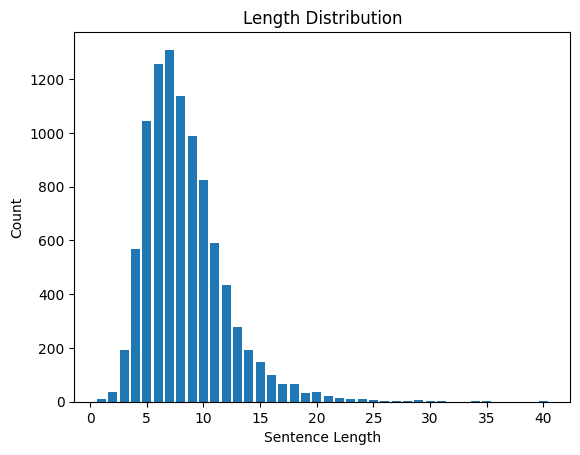

In [13]:
mean, std, total = calc_stats_from_freq(counter_a)
print(f"평균: {mean}")
print(f"표준편차: {std}")
print(f"전체 개수: {total}")

k = 2.5
max_len = math.ceil( mean + k * std )
print(f"max_len: {max_len}")

plot_counter(counter_a)

In [14]:
prepDF = trainDF.copy()

# 토큰 길이 컬럼 추가
prepDF['tok_len_q'] = prepDF['tok_q'].apply(len)
prepDF['tok_len_a'] = prepDF['tok_a'].apply(len)

# 토큰이 특정 개수 이상이면 제외
prepDF = prepDF[(prepDF['tok_len_q'] <= 16) & (prepDF['tok_len_a'] <= 18)]

print("데이터 개수: ", len(prepDF))
display(prepDF)

데이터 개수:  9078


,question,answer,label,prep_q,prep_a,tok_q,tok_a,tok_len_q,tok_len_a
0,사랑이란 뭘까?,사랑에는 답이 없어요.,1,사랑이란 뭘까?,사랑에는 답이 없어요.,"[사랑, 이란, 뭘까, ?]","[사랑, 에, 는, 답, 이, 없, 어요, .]",4,8
1,친구가 나 귀엽대,친구가 보는 눈이 있네요.,0,친구가 나 귀엽대,친구가 보는 눈이 있네요.,"[친구, 가, 나, 귀엽, 대]","[친구, 가, 보, 는, 눈, 이, 있, 네요, .]",5,9
2,끝이네,수고했어요.,1,끝이네,수고했어요.,"[끝, 이, 네]","[수고, 했, 어요, .]",3,4
3,그녀는 무슨 생각일까?ㅠ,그녀밖에 알 수가 없죠.,1,그녀는 무슨 생각일까?,그녀밖에 알 수가 없죠.,"[그녀, 는, 무슨, 생각, 일까, ?]","[그녀, 밖에, 알, 수, 가, 없, 죠, .]",6,8
5,이젠 나의 스케줄로 돌아가야할때!!,좋은 생각이에요!,1,이젠 나의 스케줄로 돌아가야할때!!,좋은 생각이에요!,"[이젠, 나, 의, 스케줄, 로, 돌아가, 야, 할, 때, !, !]","[좋, 은, 생각, 이, 에요, !]",11,6
...,...,...,...,...,...,...,...,...,...
9395,일인자가 되려면 얼마나 노력해야할까?,인내의 시간이 필요할 거예요.,0,일인자가 되려면 얼마나 노력해야할까?,인내의 시간이 필요할 거예요.,"[일인자, 가, 되, 려면, 얼마나, 노력, 해야, 할까, ?]","[인내, 의, 시간, 이, 필요, 할, 거, 예요, .]",9,9
9396,더워서 죽을 듯한 날씨야,찬물 샤워를 해보세요.,0,더워서 죽을 듯한 날씨야,찬물 샤워를 해보세요.,"[더워서, 죽, 을, 듯, 한, 날씨, 야]","[찬물, 샤워, 를, 해, 보, 세요, .]",7,7
9397,이별이 다시 올거 같은 느낌,더 두렵겠네요.,1,이별이 다시 올거 같은 느낌,더 두렵겠네요.,"[이별, 이, 다시, 올, 거, 같, 은, 느낌]","[더, 두렵, 겠, 네요, .]",8,5
9398,붙잡고 싶은데 힘이 드네,자신의 마음을 다독여주세요.,1,붙잡고 싶은데 힘이 드네,자신의 마음을 다독여주세요.,"[붙잡, 고, 싶, 은데, 힘, 이, 드, 네]","[자신, 의, 마음, 을, 다독여, 주, 세요, .]",8,8


## **Step 4. Augmentation**

In [15]:
from io import BytesIO
import gensim
from gensim.models import KeyedVectors
import zipfile
import urllib.request
import os
import numpy as np
import pickle
import torch

#### **이슈 발생**
현재 인터넷에 공개되어 있는 kyubyong/word2vec 모델은 gensim 3x에서 개발되었고, binary format이 틀림 지금 현재 최신 gensim은 4.4이고, 이 모델 binary를 읽을 수 없음 왠만한 제안들이 python 3.8이하에 gensim 3x 를 사용하라고 제안하지만, 그러고 싶지 않음 그래서 객체에 그대로 불러드리는 것이 아니라, 순수 binary만 읽어들여서 그것을 객체에 넣은 후 다시 저장하는 방법을 구현함.

- gensim: 텍스트를 숫자로 바꾸고, 그 속에서 의미를 찾아내는 자연어 처리(NLP) 전문 라이브러리
- pickle: 파이썬에서 쓰던 변수, 리스트, 딕셔너리, 심지어 인공지능 모델(객체) 그 자체를 파일로 저장했다가 나중에 그대로 다시 꺼낼 수 있음

https://recipesds.tistory.com/entry/word2vec%EC%9D%84-gensim-4x-%EC%9A%A9%EC%9C%BC%EB%A1%9C-%EC%97%85%EA%B7%B8%EB%A0%88%EC%9D%B4%EB%93%9C-%ED%95%98%EB%8A%94-%EB%B2%95

In [16]:
wordvec_path = './ko.bin'
converted_model_path = './ko_w2v_format.bin'

# 2. pickle 파일을 바이트 스트림으로 로드하고, 내부 데이터만 추출
with open(wordvec_path, 'rb') as f:
    file_bytes = BytesIO(f.read())
    unpickler = pickle.Unpickler(file_bytes, encoding='latin1')
    old_model_data = unpickler.load()

# 3. old_model_data에서 직접 벡터와 단어 목록 추출
word_vectors = old_model_data.syn0
word_key_to_index = {word: index for index, word in enumerate(old_model_data.index2word)}

# 4. 새로운 KeyedVectors 객체로 재구성
new_kv = KeyedVectors(vector_size=word_vectors.shape[1])
new_kv.add_vectors(list(word_key_to_index.keys()), word_vectors)

# 5. 표준 word2vec 포맷으로 저장
new_kv.save_word2vec_format(converted_model_path, binary=True)
print("모델 변환 완료. 새로운 파일: ko_w2v_format.bin")

# 6. 변환된 모델을 KeyedVectors로 로드하여 사용
loaded_model = KeyedVectors.load_word2vec_format(converted_model_path, binary=True)
print("최종 모델 로드 완료.")

# 모델 사용
print(loaded_model.most_similar('한국'))

모델 변환 완료. 새로운 파일: ko_w2v_format.bin
최종 모델 로드 완료.
[('대한민국', 0.6662065386772156), ('우리나라', 0.6312342882156372), ('동양', 0.5589770078659058), ('미국', 0.5445788502693176), ('동북아', 0.5333539247512817), ('국내', 0.5278753042221069), ('일본', 0.5174023509025574), ('아세아', 0.5054686069488525), ('중국', 0.5036406517028809), ('민간', 0.5017623901367188)]


In [17]:
def lexical_sub(sentence, wv):
    # 문장을 토큰화
    tokens = sentence.split()

    # 유효한 단어 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokens if tok in wv]

    # 대체할 단어 선택 (임베딩 내 존재하는 단어 중 하나)
    if not valid_tokens:
        return sentence  # 모든 단어가 임베딩 내에 없으면 원래 문장 반환

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = wv.most_similar(selected_tok)[0][0]

    # 변환된 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])

    return new_sentence

#### **Augmentation 테스트**

In [18]:
from tqdm.notebook import tqdm
import random

new_corpus = []
raw_q = list(prepDF.question)

for old_src in tqdm(raw_q):
    new_src = lexical_sub(old_src, loaded_model)
    if new_src is not None:
        new_corpus.append(new_src)
    # Augmentation이 없더라도 원본 문장을 포함시킵니다
    new_corpus.append(old_src)

print(new_corpus[:10])

  0%|          | 0/9078 [00:00<?, ?it/s]

['사랑이란 뭘까?', '사랑이란 뭘까?', '친구가 나의 귀엽대', '친구가 나 귀엽대', '끝이네', '끝이네', '그녀는 어찌 생각일까?ㅠ', '그녀는 무슨 생각일까?ㅠ', '뉘른 나의 스케줄로 돌아가야할때!!', '이젠 나의 스케줄로 돌아가야할때!!']


#### **Augmentation 진행**

In [19]:
tmpDF = prepDF.copy()

# 데이터 증강
tmpDF['aug_q'] = tmpDF['question'].apply(lambda x: lexical_sub(x, loaded_model))
tmpDF['aug_a'] = tmpDF['answer'].apply(lambda x: lexical_sub(x, loaded_model))

# 증강 데이터 토큰화
tmpDF['aug_tok_q'] = tmpDF['aug_q'].apply(tokenizer)
tmpDF['aug_tok_a'] = tmpDF['aug_a'].apply(tokenizer)

# display(tmpDF)

In [20]:
corpusDF_A = tmpDF[['question', 'answer', 'tok_q', 'tok_a']]
corpusDF_B = tmpDF[['question', 'answer', 'aug_tok_q', 'tok_a']].rename(columns={'aug_tok_q': 'tok_q'})
corpusDF_C = tmpDF[['question', 'answer', 'tok_q', 'aug_tok_a']].rename(columns={'aug_tok_a': 'tok_a'})

corpusDF = pd.concat([corpusDF_A, corpusDF_B, corpusDF_C], axis=0)

print(len(corpusDF))
# display(corpusDF)

27234


## **Step 5. 데이터 벡터화**

In [21]:
corpusDF['tok_q'] = corpusDF['tok_q'].apply(lambda x: ['<start>'] + x + ['<end>'])
corpusDF['tok_a'] = corpusDF['tok_a'].apply(lambda x: ['<start>'] + x + ['<end>'])
corpusDF['tmp_kor'] = corpusDF['question'] + " " + corpusDF['answer']

display(corpusDF)

,question,answer,tok_q,tok_a,tmp_kor
0,사랑이란 뭘까?,사랑에는 답이 없어요.,"[<start>, 사랑, 이란, 뭘까, ?, <end>]","[<start>, 사랑, 에, 는, 답, 이, 없, 어요, ., <end>]",사랑이란 뭘까? 사랑에는 답이 없어요.
1,친구가 나 귀엽대,친구가 보는 눈이 있네요.,"[<start>, 친구, 가, 나, 귀엽, 대, <end>]","[<start>, 친구, 가, 보, 는, 눈, 이, 있, 네요, ., <end>]",친구가 나 귀엽대 친구가 보는 눈이 있네요.
2,끝이네,수고했어요.,"[<start>, 끝, 이, 네, <end>]","[<start>, 수고, 했, 어요, ., <end>]",끝이네 수고했어요.
3,그녀는 무슨 생각일까?ㅠ,그녀밖에 알 수가 없죠.,"[<start>, 그녀, 는, 무슨, 생각, 일까, ?, <end>]","[<start>, 그녀, 밖에, 알, 수, 가, 없, 죠, ., <end>]",그녀는 무슨 생각일까?ㅠ 그녀밖에 알 수가 없죠.
5,이젠 나의 스케줄로 돌아가야할때!!,좋은 생각이에요!,"[<start>, 이젠, 나, 의, 스케줄, 로, 돌아가, 야, 할, 때, !, !...","[<start>, 좋, 은, 생각, 이, 에요, !, <end>]",이젠 나의 스케줄로 돌아가야할때!! 좋은 생각이에요!
...,...,...,...,...,...
9395,일인자가 되려면 얼마나 노력해야할까?,인내의 시간이 필요할 거예요.,"[<start>, 일인자, 가, 되, 려면, 얼마나, 노력, 해야, 할까, ?, <...","[<start>, 인내, 의, 시간, 이, 필요, 할, 거, 예요, ., <end>]",일인자가 되려면 얼마나 노력해야할까? 인내의 시간이 필요할 거예요.
9396,더워서 죽을 듯한 날씨야,찬물 샤워를 해보세요.,"[<start>, 더워서, 죽, 을, 듯, 한, 날씨, 야, <end>]","[<start>, 끼얹, 샤, 워, 를, 해, 보, 세요, ., <end>]",더워서 죽을 듯한 날씨야 찬물 샤워를 해보세요.
9397,이별이 다시 올거 같은 느낌,더 두렵겠네요.,"[<start>, 이별, 이, 다시, 올, 거, 같, 은, 느낌, <end>]","[<start>, 던, 두렵, 겠, 네요, ., <end>]",이별이 다시 올거 같은 느낌 더 두렵겠네요.
9398,붙잡고 싶은데 힘이 드네,자신의 마음을 다독여주세요.,"[<start>, 붙잡, 고, 싶, 은데, 힘, 이, 드, 네, <end>]","[<start>, 자신, 의, 마음, 을, 다독여, 주, 세요, ., <end>]",붙잡고 싶은데 힘이 드네 자신의 마음을 다독여주세요.


In [22]:
from collections import Counter

# 1. 모든 행의 리스트를 하나의 리스트로 펼치기 (Flatten)
# df['A']가 질문하신 리스트 형태의 컬럼이라고 가정합니다.
q_tokens = [token for sublist in corpusDF['tok_q'] for token in sublist]
a_tokens = [token for sublist in corpusDF['tok_a'] for token in sublist]

# 2. Counter를 사용하여 단어별 빈도수 계산
token_counts = Counter(q_tokens + a_tokens)

# 3. 빈도수 기준으로 내림차순 정렬
# 결과: [('단어', 빈도), ('단어', 빈도), ...]
sorted_tokens = token_counts.most_common()

# 4. 전체 단어 등장 횟수 합계 (Total Frequency)
total_freq = sum(token_counts.values())
target_freq = total_freq * 0.99  # 99% 지점 목표치

# 5. 누적 빈도를 계산하며 99% 지점 찾기
cumulative_freq = 0
vocab_size_99 = 0

for i, (token, freq) in enumerate(sorted_tokens):
    cumulative_freq += freq
    if cumulative_freq >= target_freq:
        vocab_size_99 = i + 1  # 인덱스가 0부터 시작하므로 +1
        break

print(f"전체 고유 단어 수: {len(token_counts)}개")
print(f"전체 단어 발생 횟수: {total_freq}회")
print(f"데이터의 99%를 커버하는 단어 수(vocab_size): {vocab_size_99}개")

전체 고유 단어 수: 7047개
전체 단어 발생 횟수: 515492회
데이터의 99%를 커버하는 단어 수(vocab_size): 4969개


#### **단어장 구축**

In [23]:
from konlpy.tag import Mecab
import tensorflow as tf

# 1. 문장을 쪼개주는 형태소 분석기 준비
mecab = Mecab()

# (미리 데이터프레임의 한국어 문장들을 쪼개서 리스트로 만들어 둡니다)
q_tokens = list(corpusDF['tok_q'])
a_tokens = list(corpusDF['tok_a'])
kor_tokens = q_tokens + a_tokens

# 2. 인코더 토크나이저 정의 (글자를 숫자로 바꾸고 단어장을 관리)
vocab_size = 5000
encoder_tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=vocab_size, 
    oov_token="<unk>", # 단어장에 없는 모르는 단어가 나왔을 때 처리할 이름
    filters=''
)

# 3. 내 데이터(kor_tokens)를 보고 즉석에서 단어장 학습(구축)하기
# SentencePiece의 .train() 과 비슷한 역할입니다.
encoder_tokenizer.fit_on_texts(kor_tokens)

2026-03-12 04:54:44.396082: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 04:54:44.424558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 04:54:45.558200: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [24]:
kor_sample = list(corpusDF["tmp_kor"])[1000]

morphs = mecab.morphs(kor_sample)
enc_token = encoder_tokenizer.texts_to_sequences([morphs])[0]
print(enc_token)
enc_decoding = encoder_tokenizer.sequences_to_texts([enc_token])[0]
print(enc_decoding)

[1821, 1461, 224, 10, 1607, 4, 1265, 6, 24, 655, 39, 13, 32, 4]
문화 센터 라도 가 야겠다 . 다양 하 게 배우 면 좋 죠 .


#### **벡터화**

In [25]:
def pad_sequences_custom(seq, max_len=20, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """

    # 초과 길이는 자르고
    if len(seq) > max_len:
        seq = seq[:max_len]
    # 부족한 길이는 pad_value로 채우기
    else:
        seq = seq + [pad_value] * (max_len - len(seq))

    return seq

    # # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    # return torch.tensor(padded_sequences, dtype=torch.long)

In [26]:
tmpDF = corpusDF.copy()

tmpDF['vec_q'] = tmpDF['tok_q'].apply(lambda x: encoder_tokenizer.texts_to_sequences([x])[0])
tmpDF['vec_a'] = tmpDF['tok_a'].apply(lambda x: encoder_tokenizer.texts_to_sequences([x])[0])
tmpDF['pad_q'] = tmpDF['vec_q'].apply(lambda x: pad_sequences_custom(x))
tmpDF['pad_a'] = tmpDF['vec_a'].apply(lambda x: pad_sequences_custom(x))

trainDF = tmpDF.reset_index(drop=True)
display(trainDF)

,question,answer,tok_q,tok_a,tmp_kor,vec_q,vec_a,pad_q,pad_a
0,사랑이란 뭘까?,사랑에는 답이 없어요.,"[<start>, 사랑, 이란, 뭘까, ?, <end>]","[<start>, 사랑, 에, 는, 답, 이, 없, 어요, ., <end>]",사랑이란 뭘까? 사랑에는 답이 없어요.,"[2, 38, 1043, 535, 20, 3]","[2, 38, 26, 7, 560, 5, 40, 28, 4, 3]","[2, 38, 1043, 535, 20, 3, 0, 0, 0, 0, 0, 0, 0,...","[2, 38, 26, 7, 560, 5, 40, 28, 4, 3, 0, 0, 0, ..."
1,친구가 나 귀엽대,친구가 보는 눈이 있네요.,"[<start>, 친구, 가, 나, 귀엽, 대, <end>]","[<start>, 친구, 가, 보, 는, 눈, 이, 있, 네요, ., <end>]",친구가 나 귀엽대 친구가 보는 눈이 있네요.,"[2, 42, 10, 21, 864, 326, 3]","[2, 42, 10, 16, 7, 223, 5, 17, 36, 4, 3]","[2, 42, 10, 21, 864, 326, 3, 0, 0, 0, 0, 0, 0,...","[2, 42, 10, 16, 7, 223, 5, 17, 36, 4, 3, 0, 0,..."
2,끝이네,수고했어요.,"[<start>, 끝, 이, 네, <end>]","[<start>, 수고, 했, 어요, ., <end>]",끝이네 수고했어요.,"[2, 117, 5, 37, 3]","[2, 1, 56, 28, 4, 3]","[2, 117, 5, 37, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 1, 56, 28, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
3,그녀는 무슨 생각일까?ㅠ,그녀밖에 알 수가 없죠.,"[<start>, 그녀, 는, 무슨, 생각, 일까, ?, <end>]","[<start>, 그녀, 밖에, 알, 수, 가, 없, 죠, ., <end>]",그녀는 무슨 생각일까?ㅠ 그녀밖에 알 수가 없죠.,"[2, 176, 7, 341, 48, 434, 20, 3]","[2, 176, 793, 101, 47, 10, 40, 32, 4, 3]","[2, 176, 7, 341, 48, 434, 20, 3, 0, 0, 0, 0, 0...","[2, 176, 793, 101, 47, 10, 40, 32, 4, 3, 0, 0,..."
4,이젠 나의 스케줄로 돌아가야할때!!,좋은 생각이에요!,"[<start>, 이젠, 나, 의, 스케줄, 로, 돌아가, 야, 할, 때, !, !...","[<start>, 좋, 은, 생각, 이, 에요, !, <end>]",이젠 나의 스케줄로 돌아가야할때!! 좋은 생각이에요!,"[2, 441, 21, 41, 4307, 94, 811, 89, 50, 79, 81...","[2, 13, 18, 48, 5, 77, 81, 3]","[2, 441, 21, 41, 4307, 94, 811, 89, 50, 79, 81...","[2, 13, 18, 48, 5, 77, 81, 3, 0, 0, 0, 0, 0, 0..."
...,...,...,...,...,...,...,...,...,...
27229,일인자가 되려면 얼마나 노력해야할까?,인내의 시간이 필요할 거예요.,"[<start>, 일인자, 가, 되, 려면, 얼마나, 노력, 해야, 할까, ?, <...","[<start>, 인내, 의, 시간, 이, 필요, 할, 거, 예요, ., <end>]",일인자가 되려면 얼마나 노력해야할까? 인내의 시간이 필요할 거예요.,"[2, 1, 10, 55, 870, 1208, 319, 113, 116, 20, 3]","[2, 1, 41, 73, 5, 118, 50, 15, 27, 4, 3]","[2, 1, 10, 55, 870, 1208, 319, 113, 116, 20, 3...","[2, 1, 41, 73, 5, 118, 50, 15, 27, 4, 3, 0, 0,..."
27230,더워서 죽을 듯한 날씨야,찬물 샤워를 해보세요.,"[<start>, 더워서, 죽, 을, 듯, 한, 날씨, 야, <end>]","[<start>, 끼얹, 샤, 워, 를, 해, 보, 세요, ., <end>]",더워서 죽을 듯한 날씨야 찬물 샤워를 해보세요.,"[2, 2627, 307, 8, 230, 33, 450, 89, 3]","[2, 1, 1, 1, 34, 14, 16, 9, 4, 3]","[2, 2627, 307, 8, 230, 33, 450, 89, 3, 0, 0, 0...","[2, 1, 1, 1, 34, 14, 16, 9, 4, 3, 0, 0, 0, 0, ..."
27231,이별이 다시 올거 같은 느낌,더 두렵겠네요.,"[<start>, 이별, 이, 다시, 올, 거, 같, 은, 느낌, <end>]","[<start>, 던, 두렵, 겠, 네요, ., <end>]",이별이 다시 올거 같은 느낌 더 두렵겠네요.,"[2, 66, 5, 173, 418, 15, 31, 18, 344, 3]","[2, 92, 2710, 25, 36, 4, 3]","[2, 66, 5, 173, 418, 15, 31, 18, 344, 3, 0, 0,...","[2, 92, 2710, 25, 36, 4, 3, 0, 0, 0, 0, 0, 0, ..."
27232,붙잡고 싶은데 힘이 드네,자신의 마음을 다독여주세요.,"[<start>, 붙잡, 고, 싶, 은데, 힘, 이, 드, 네, <end>]","[<start>, 자신, 의, 마음, 을, 다독여, 주, 세요, ., <end>]",붙잡고 싶은데 힘이 드네 자신의 마음을 다독여주세요.,"[2, 606, 12, 35, 166, 416, 5, 301, 37, 3]","[2, 107, 41, 52, 8, 2867, 57, 9, 4, 3]","[2, 606, 12, 35, 166, 416, 5, 301, 37, 3, 0, 0...","[2, 107, 41, 52, 8, 2867, 57, 9, 4, 3, 0, 0, 0..."


#### **validation 데이터셋 정의**

In [27]:
tmpDF = valDF.copy()

tmpDF['vec_q'] = tmpDF['tok_q'].apply(lambda x: encoder_tokenizer.texts_to_sequences([x])[0])
tmpDF['vec_a'] = tmpDF['tok_a'].apply(lambda x: encoder_tokenizer.texts_to_sequences([x])[0])
tmpDF['pad_q'] = tmpDF['vec_q'].apply(lambda x: pad_sequences_custom(x))
tmpDF['pad_a'] = tmpDF['vec_a'].apply(lambda x: pad_sequences_custom(x))

valDF = tmpDF.reset_index(drop=True)
display(valDF)

,question,answer,label,prep_q,prep_a,tok_q,tok_a,vec_q,vec_a,pad_q,pad_a
0,이성의 학교선배와 단둘이 식사한다면 어떻게 해?,신경쓰인다고 귀엽게 이야기해보세요.,2,이성의 학교선배와 단둘이 식사한다면 어떻게 해?,신경쓰인다고 귀엽게 이야기해보세요.,"[이성, 의, 학교, 선배, 와, 단, 둘, 이, 식사, 한다면, 어떻게, 해, ?]","[신경, 쓰인다고, 귀엽, 게, 이야기, 해, 보, 세요, .]","[969, 41, 532, 1498, 162, 968, 495, 5, 2959, 8...","[225, 1, 864, 24, 197, 14, 16, 9, 4]","[969, 41, 532, 1498, 162, 968, 495, 5, 2959, 8...","[225, 1, 864, 24, 197, 14, 16, 9, 4, 0, 0, 0, ..."
1,구여친이랑 헤어진지 꽤 됐는데 좋아하는 사람이 없음.,조급하게 생각하지 않아도 된답니다.,2,구여친이랑 헤어진지 꽤 됐는데 좋아하는 사람이 없음.,조급하게 생각하지 않아도 된답니다.,"[구, 여친, 이랑, 헤어진지, 꽤, 됐, 는데, 좋, 아, 하, 는, 사람, 이,...","[조급, 하, 게, 생각, 하, 지, 않, 아도, 된답니다, .]","[775, 228, 157, 213, 2141, 199, 53, 13, 23, 6,...","[1366, 6, 24, 48, 6, 19, 54, 479, 1, 4]","[775, 228, 157, 213, 2141, 199, 53, 13, 23, 6,...","[1366, 6, 24, 48, 6, 19, 54, 479, 1, 4, 0, 0, ..."
2,짝녀가 나한테 관심이 전혀 없는 듯.,나의 존재를 먼저 인지시켜보세요.,2,짝녀가 나한테 관심이 전혀 없는 듯.,나의 존재를 먼저 인지시켜보세요.,"[짝, 녀, 가, 나, 한테, 관심, 이, 전혀, 없, 는, 듯, .]","[나, 의, 존재, 를, 먼저, 인지, 시켜, 보, 세요, .]","[95, 215, 10, 21, 87, 358, 5, 3044, 40, 7, 230...","[21, 41, 1025, 34, 253, 249, 569, 16, 9, 4]","[95, 215, 10, 21, 87, 358, 5, 3044, 40, 7, 230...","[21, 41, 1025, 34, 253, 249, 569, 16, 9, 4, 0,..."
3,결국 헤어졌네,더 좋은 사람 만나실 거예요.,1,결국 헤어졌네,더 좋은 사람 만나실 거예요.,"[결국, 헤어졌, 네]","[더, 좋, 은, 사람, 만나, 실, 거, 예요, .]","[380, 293, 37]","[68, 13, 18, 29, 96, 810, 15, 27, 4]","[380, 293, 37, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[68, 13, 18, 29, 96, 810, 15, 27, 4, 0, 0, 0, ..."
4,2년의 연애에 이별이란 종착역!!,다른 역을 향해 떠나요.,1,2년의 연애에 이별이란 종착역!!,다른 역을 향해 떠나요.,"[2, 년, 의, 연애, 에, 이별, 이란, 종착역, !, !]","[다른, 역, 을, 향해, 떠나, 요, .]","[269, 124, 41, 120, 26, 66, 1043, 1, 81, 81]","[164, 1, 8, 1, 645, 90, 4]","[269, 124, 41, 120, 26, 66, 1043, 1, 81, 81, 0...","[164, 1, 8, 1, 645, 90, 4, 0, 0, 0, 0, 0, 0, 0..."
...,...,...,...,...,...,...,...,...,...,...,...
2345,짝남 정리 잘하고 있었는데 자꾸 꿈에 나와.,생각을 많이 해서 그럴지도 몰라요.,2,짝남 정리 잘하고 있었는데 자꾸 꿈에 나와.,생각을 많이 해서 그럴지도 몰라요.,"[짝, 남, 정리, 잘, 하, 고, 있, 었, 는데, 자꾸, 꿈, 에, 나와, .]","[생각, 을, 많이, 해서, 그럴지, 도, 몰라요, .]","[95, 83, 134, 51, 6, 12, 17, 60, 53, 220, 204,...","[48, 8, 70, 217, 1, 22, 254, 4]","[95, 83, 134, 51, 6, 12, 17, 60, 53, 220, 204,...","[48, 8, 70, 217, 1, 22, 254, 4, 0, 0, 0, 0, 0,..."
2346,화장실!!,화장실 가세요.,0,화장실!!,화장실 가세요.,"[화장실, !, !]","[화장실, 가, 세요, .]","[1308, 81, 81]","[1308, 10, 9, 4]","[1308, 81, 81, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[1308, 10, 9, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2347,6개월이 지나도 왜이런거죠?,물리적 시간에 비례하지 않으니까요.,1,6개월이 지나도 왜이런거죠?,물리적 시간에 비례하지 않으니까요.,"[6, 개월, 이, 지, 나, 도, 왜, 이런, 거, 죠, ?]","[물리, 적, 시간, 에, 비례, 하, 지, 않, 으니까요, .]","[588, 346, 5, 19, 21, 22, 141, 317, 15, 32, 20]","[1747, 91, 73, 26, 1, 6, 19, 54, 476, 4]","[588, 346, 5, 19, 21, 22, 141, 317, 15, 32, 20...","[1747, 91, 73, 26, 1, 6, 19, 54, 476, 4, 0, 0,..."
2348,내가 제일 문제인 듯,당신은 하나밖에 없는 소중한 사람이에요.,0,내가 제일 문제인 듯,당신은 하나밖에 없는 소중한 사람이에요.,"[내, 가, 제일, 문제, 인, 듯]","[당신, 은, 하나, 밖에, 없, 는, 소중, 한, 사람, 이, 에요, .]","[65, 10, 437, 381, 108, 230]","[110, 18, 174, 793, 40, 7, 718, 33, 29, 5, 77, 4]","[65, 10, 437, 381, 108, 230, 0, 0, 0, 0, 0, 0,...","[110, 18, 174, 793, 40, 7, 718, 33, 29, 5, 77,..."


In [28]:
from torch.utils.data import TensorDataset, DataLoader

def ChatBotDataloader(dataframe, batch_size=64):
    pad_q_list = list(dataframe['pad_q'])
    pad_a_list = list(dataframe['pad_a'])
    
    q_ndarray = torch.tensor(pad_q_list, dtype=torch.long)
    a_ndarray = torch.tensor(pad_a_list, dtype=torch.long)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = TensorDataset(q_ndarray, a_ndarray)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    
    return dataloader

In [29]:
train_dataloader = ChatBotDataloader(trainDF)
val_dataloader = ChatBotDataloader(valDF)

### **번역 모델 만들기**

#### **트랜스포머 구현하기**

##### Positional Encoding

In [30]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

슝=3


##### 마스크 생성

In [31]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


##### Multi-head Attention

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


##### Position-wise Feed Forward Network

In [33]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


##### Encoder Layer

In [34]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


##### Decoder Layer

In [35]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


##### Encoder

In [36]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")

슝=3


##### Decoder

In [37]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


##### Transformer 전체 모델 조립

In [38]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


##### 모델 인스턴스 생성

In [39]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=vocab_size,
    tgt_vocab_size=vocab_size,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)

d_model = 512

print("슝=3")

슝=3


##### Learning Rate Scheduler

In [40]:
# warmup_steps = 60 -> 4000

class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=200):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


##### Learning Rate & Optimizer

In [41]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


##### Loss Function 정의

In [42]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


##### Train Step 정의

In [43]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [44]:
def validation_step(src, tgt, model):
    model.eval()  # 1. 모델을 평가(evaluation) 모드로 전환 (드롭아웃 등 비활성화)
    
    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    # 텐서들을 GPU/CPU로 이동 
    # (💡주의: loss 계산을 위해 gold도 device로 보내주어야 에러가 나지 않습니다!)
    src = src.to(device)
    tgt_in = tgt_in.to(device)
    gold = gold.to(device) 
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 2. 기울기(Gradient) 계산 비활성화 (검증 시 필수)
    with torch.no_grad():
        # 모델 forward pass
        predictions, enc_attns, dec_attns, dec_enc_attns = model(
            src, tgt_in, enc_mask, dec_enc_mask, dec_mask
        )

        # loss 계산
        loss = loss_function(gold, predictions)

    # 3. 역전파(backward) 및 옵티마이저(step) 삭제됨

    return loss, enc_attns, dec_attns, dec_enc_attns

In [45]:
import torch

def train_model(model, train_dataloader, val_dataloader, optimizer, lr_scheduler, 
                epochs=50, patience=3, save_path='best_transformer_model.pt'):
    
    print("🚀 학습을 시작합니다!")
    counter = 0
    best_val_loss = float('inf')

    history_train_loss = []
    history_val_loss = []

    step_num = 0

    for epoch in range(epochs):
        # -------------------------
        # [1] Training Phase
        # -------------------------
        model.train()
        total_train_loss = 0.0
        
        for src, tgt in train_dataloader:
            step_num += 1
            # 스케줄러로 현재 스텝의 학습률 계산 및 적용
            lr = lr_scheduler(step_num)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            # 기존에 만드신 train_step 호출 (전역 함수로 정의되어 있어야 함)
            loss, _, _, _ = train_step(src, tgt, model, optimizer)
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_dataloader)
        history_train_loss.append(avg_train_loss)

        # -------------------------
        # [2] Validation Phase
        # -------------------------
        model.eval()
        total_val_loss = 0.0
        
        with torch.no_grad():
            for src, tgt in val_dataloader: 
                # 기존에 만드신 validation_step 호출
                loss, _, _, _ = validation_step(src, tgt, model)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_dataloader)
        history_val_loss.append(avg_val_loss)
        
        # 결과 출력
        print(f"Epoch {epoch+1:02d}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # -------------------------
        # [3] Early Stopping & Model Save
        # -------------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ 모델 저장 완료 (Best Val Loss: {best_val_loss:.4f})")
        else:
            counter += 1
            print(f"  ⚠️ 개선되지 않음 (Count: {counter}/{patience})")
            if counter >= patience:
                print("🛑 Early Stopping: 오차가 더 이상 줄어들지 않아 학습을 조기 중단합니다.")
                break

    print("🎉 학습이 모두 종료되었습니다!")
    return history_train_loss, history_val_loss

In [46]:
# 함수 실행! (에포크나 patience를 입맛대로 바꿀 수 있습니다)
train_losses, val_losses = train_model(
    model=transformer, 
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    optimizer=optimizer, 
    lr_scheduler=learning_rate, # 아까 만드신 LearningRateScheduler 인스턴스
    epochs=50, 
    patience=3,
    save_path='best_transformer_model_A.pt'
)

🚀 학습을 시작합니다!
Epoch 01/50 - Train Loss: 3780.0280, Val Loss: 1906.1875
  ✅ 모델 저장 완료 (Best Val Loss: 1906.1875)
Epoch 02/50 - Train Loss: 1578.8911, Val Loss: 936.0160
  ✅ 모델 저장 완료 (Best Val Loss: 936.0160)
Epoch 03/50 - Train Loss: 978.7889, Val Loss: 585.7703
  ✅ 모델 저장 완료 (Best Val Loss: 585.7703)
Epoch 04/50 - Train Loss: 728.6773, Val Loss: 463.8517
  ✅ 모델 저장 완료 (Best Val Loss: 463.8517)
Epoch 05/50 - Train Loss: 588.8035, Val Loss: 377.2322
  ✅ 모델 저장 완료 (Best Val Loss: 377.2322)
Epoch 06/50 - Train Loss: 485.8280, Val Loss: 324.0564
  ✅ 모델 저장 완료 (Best Val Loss: 324.0564)
Epoch 07/50 - Train Loss: 423.2976, Val Loss: 287.9330
  ✅ 모델 저장 완료 (Best Val Loss: 287.9330)
Epoch 08/50 - Train Loss: 380.9121, Val Loss: 258.8563
  ✅ 모델 저장 완료 (Best Val Loss: 258.8563)
Epoch 09/50 - Train Loss: 348.2527, Val Loss: 240.9795
  ✅ 모델 저장 완료 (Best Val Loss: 240.9795)
Epoch 10/50 - Train Loss: 328.8823, Val Loss: 222.5892
  ✅ 모델 저장 완료 (Best Val Loss: 222.5892)
Epoch 11/50 - Train Loss: 305.3839, Val Los

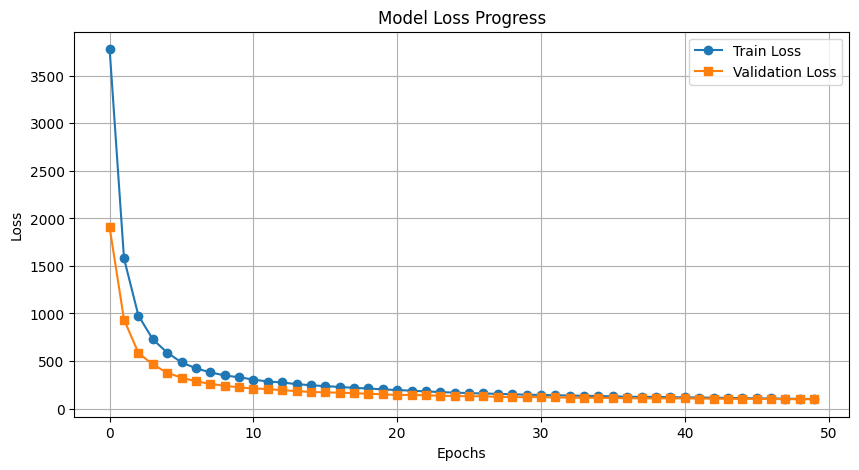

In [48]:
# 훈련 손실과 검증 손실 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
import torch

def evaluate(sentence, model, tokenizer, mecab, max_len=20):
    model.eval() # 1. 평가 모드로 전환
    
    # 2. 입력 문장 전처리 (형태소 분석 -> 숫자 번호로 변환 -> 텐서로 변환)
    tokens = mecab.morphs(sentence)
    src_indices = tokenizer.texts_to_sequences([tokens])[0]
    src = torch.tensor([src_indices], dtype=torch.long).to(device)
    
    # 3. 디코더의 첫 입력으로 <start> 토큰 부여
    # (주의: 단어장에 등록된 '<start>'와 '<end>'의 실제 모양에 맞춰주세요)
    start_id = tokenizer.word_index.get('<start>')
    end_id = tokenizer.word_index.get('<end>')
    
    if start_id is None or end_id is None:
        return "오류: 단어장에 <start> 또는 <end> 토큰이 없습니다."
        
    tgt_in = torch.tensor([[start_id]], dtype=torch.long).to(device)
    
    result_tokens = []
    
    # 4. 단어를 하나씩 생성하는 루프 (최대 max_len 번 반복)
    with torch.no_grad():
        for i in range(max_len):
            # 마스크 생성 (입력 문장과 현재까지 만들어진 타겟 문장 기준)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            
            # 모델 예측 (다음 단어 후보들의 확률값)
            predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            
            # 가장 마지막 시점(방금 예측한 단어)에서 확률이 가장 높은 단어의 번호 추출
            pred_token_id = predictions[:, -1, :].argmax(dim=-1).item()
            
            # 만약 예측한 단어가 <end> 토큰이면 문장 생성 종료
            if pred_token_id == end_id:
                break
                
            # 결과 리스트에 예측한 단어 번호 추가
            result_tokens.append(pred_token_id)
            
            # 방금 예측한 단어를 다음 스텝의 입력(tgt_in) 뒤에 이어 붙임
            pred_tensor = torch.tensor([[pred_token_id]], dtype=torch.long).to(device)
            tgt_in = torch.cat([tgt_in, pred_tensor], dim=-1)
            
    # 5. 숫자 번호 리스트를 다시 사람이 읽을 수 있는 텍스트로 변환
    decoded_sentence = tokenizer.sequences_to_texts([result_tokens])[0]
    
    return decoded_sentence

In [50]:
# 테스트해 볼 질문 문자열
question = "나 오늘 너무 피곤해."

# 결과 출력
answer = evaluate(question, transformer, encoder_tokenizer, mecab)
print(f"질문: {question}")
print(f"챗봇 대답: {answer}")

질문: 나 오늘 너무 피곤해.
챗봇 대답: 맛나 게 드세요 .


## **Step 7. 성능 측정하기**

In [77]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm

In [82]:
def eval_bleu_single(model, src_sentence, tgt_sentence, tokenizer, mecab, max_len=50, verbose=False):
    model.eval() # 평가 모드
    
    # 1. 모델에게 질문을 던져서 '예측된 대답(Candidate)'을 텍스트로 받아옵니다.
    # (주의: 여기서 쓰인 translate 또는 evaluate 함수는 문자열을 넣으면 문자열을 뱉도록 
    # 정상적으로 구현되어 있어야 합니다!)
    pred_sentence = evaluate(src_sentence, model, tokenizer, mecab, max_len)
    
    # 만약 예측을 실패해서 아무것도 안 나왔다면 0점 처리
    if not pred_sentence: return 0.0

    # 2. 텍스트를 공백(띄어쓰기) 기준으로 잘라서 단어 리스트로 만듭니다.
    # 예: "나는 학생 이다" -> ['나는', '학생', '이다']
    reference = tgt_sentence.split()
    candidate = pred_sentence.split()
    
    # 3. BLEU 점수 계산 (SmoothingFunction은 짧은 문장에서 0점이 나오는 것을 방지해 줍니다)
    smoothie = SmoothingFunction().method1
    score = sentence_bleu([reference], candidate, smoothing_function=smoothie)
    
    # verbose가 True면 화면에 결과를 예쁘게 출력해 줍니다.
    if verbose:
        print(f"원래 질문 (Source): {src_sentence}")
        print(f"실제 정답 (Reference): {tgt_sentence}")
        print(f"모델 예측 (Candidate): {pred_sentence}")
        print(f"=> BLEU Score: {score:.4f}\n" + "-"*30)
        
    return score

In [83]:
def eval_bleu(model, val_src_list, val_tgt_list, tokenizer, mecab, sample_size=None):
    total_score = 0.0
    
    # 시간이 너무 오래 걸린다면 sample_size를 지정해서 일부만 평가할 수도 있습니다.
    if sample_size is None:
        sample_size = len(val_src_list)
        
    print(f"총 {sample_size}개의 문장에 대해 BLEU 평가를 시작합니다...")
    
    # tqdm으로 진행률 표시
    for i in tqdm(range(sample_size)):
        src = val_src_list[i]
        tgt = val_tgt_list[i]
        
        # verbose=False로 두어 전체 평가 시에는 화면을 도배하지 않도록 합니다.
        score = eval_bleu_single(model, src, tgt, tokenizer, mecab, verbose=False)
        total_score += score
        
    avg_bleu = total_score / sample_size
    print(f"\n🎉 최종 평균 BLEU 점수: {avg_bleu:.4f}")
    
    return avg_bleu

In [84]:
val_q = list(valDF['question'])
val_a = list(valDF['answer'])

In [85]:
val_bleu_score = eval_bleu(transformer, val_q, val_a, encoder_tokenizer, mecab)

총 2350개의 문장에 대해 BLEU 평가를 시작합니다...


100%|█████████████████████████████████████████████████████████████| 2350/2350 [01:35<00:00, 24.72it/s]


🎉 최종 평균 BLEU 점수: 0.0004


### 중간 결과

#### 설정
- Epoch : 50
- warmup_steps : 200

#### 하이퍼 파라미터
- n_layers=2
- d_model=512
- n_heads=8
- d_ff=2048
- src_vocab_size=5000
- tgt_vocab_size=vocab_size
- pos_len=200
- dropout=0.3
- shared_fc=True
- shared_emb=True


#### 문제
- Loss가 너무 크게 나옴
- 수렴도 굉장히 늦게 됨
- 문장 생성도 반복적인 단어가 나오며 생성 실패
- BLEU : 0.0004 -> 거의 단 한 개도 맞히지 못하고 있다

#### 개선 사항
- loss를 먼저 개선 시키는 게 먼저인듯!
  - '자비에르(Xavier) 초기화' 기법 : 입력 데이터와 출력 데이터의 양을 계산해서, 숫자들이 층을 통과해도 일정한 크기를 유지하도록 아주 똑똑하게 채워 넣음 

### 실험1

In [98]:
import torch.nn as nn

# 뇌세포 예쁘게 정렬하는 마법의 함수
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

In [107]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=vocab_size,
    tgt_vocab_size=vocab_size,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

# 모델 선언 후 반드시 이 함수를 먹여줍니다!
transformer.apply(initialize_weights)

transformer = transformer.to(device)

d_model = 512

print("슝=3")

슝=3


In [108]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model, warmup_steps=4000)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


In [109]:
# 함수 실행! (에포크나 patience를 입맛대로 바꿀 수 있습니다)
train_losses, val_losses = train_model(
    model=transformer, 
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    optimizer=optimizer, 
    lr_scheduler=learning_rate, # 아까 만드신 LearningRateScheduler 인스턴스
    epochs=50, 
    patience=3,
    save_path='best_transformer_model_B.pt'
)

🚀 학습을 시작합니다!
Epoch 01/50 - Train Loss: 5.8699, Val Loss: 4.7673
  ✅ 모델 저장 완료 (Best Val Loss: 4.7673)
Epoch 02/50 - Train Loss: 4.0706, Val Loss: 3.9334
  ✅ 모델 저장 완료 (Best Val Loss: 3.9334)
Epoch 03/50 - Train Loss: 3.3442, Val Loss: 3.3935
  ✅ 모델 저장 완료 (Best Val Loss: 3.3935)
Epoch 04/50 - Train Loss: 2.7743, Val Loss: 3.1603
  ✅ 모델 저장 완료 (Best Val Loss: 3.1603)
Epoch 05/50 - Train Loss: 2.2551, Val Loss: 3.1936
  ⚠️ 개선되지 않음 (Count: 1/3)
Epoch 06/50 - Train Loss: 1.8472, Val Loss: 3.2920
  ⚠️ 개선되지 않음 (Count: 2/3)
Epoch 07/50 - Train Loss: 1.5598, Val Loss: 3.4663
  ⚠️ 개선되지 않음 (Count: 3/3)
🛑 Early Stopping: 오차가 더 이상 줄어들지 않아 학습을 조기 중단합니다.
🎉 학습이 모두 종료되었습니다!


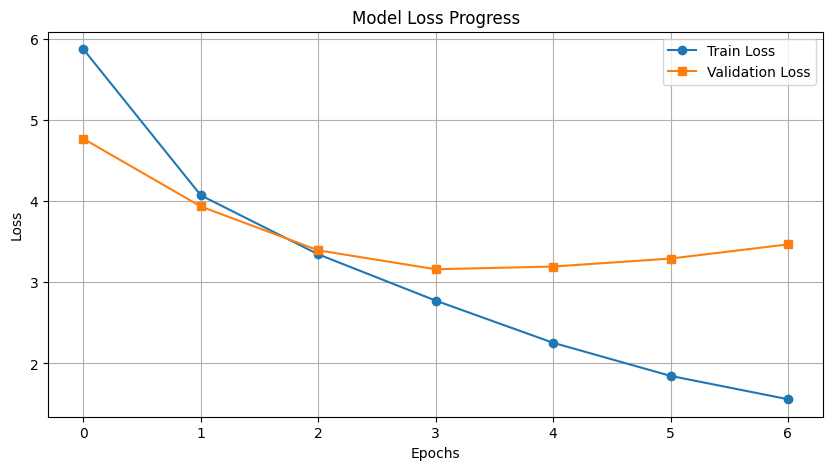

In [112]:
# 훈련 손실과 검증 손실 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [110]:
# 테스트해 볼 질문 문자열
question = "나 오늘 너무 피곤해."

# 결과 출력
answer = evaluate(question, transformer, encoder_tokenizer, mecab)
print(f"질문: {question}")
print(f"챗봇 대답: {answer}")

질문: 나 오늘 너무 피곤해.
챗봇 대답: 요즘 바쁜가 봐요 .


In [111]:
val_bleu_score = eval_bleu(transformer, val_q, val_a, encoder_tokenizer, mecab)

총 2350개의 문장에 대해 BLEU 평가를 시작합니다...


100%|█████████████████████████████████████████████████████████████| 2350/2350 [01:25<00:00, 27.48it/s]


🎉 최종 평균 BLEU 점수: 0.0024


### 실험1 결과

#### 설정
- Epoch : 4
- warmup_steps : 4000 -> "Attention Is All You Need" 논문에서 제시한 표준

#### 결과
- Loss가 크게 낮아짐 (98.1717 -> 3.1603)
- 질문에 대한 대답은 자연스러운 것 같음  
  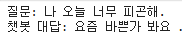
- BLEU는 0.0024로 사실상 불일치로 나옴
  - 답변의 맥락은 잘 생성한 것 같음
  - BLEU가 챗봇 모델의 성능을 판단하기에는 적절하지 않는 것으로 판단됨

### 실험2

In [126]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=vocab_size,
    tgt_vocab_size=vocab_size,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

# 모델 선언 후 반드시 이 함수를 먹여줍니다!
transformer.apply(initialize_weights)

transformer = transformer.to(device)

d_model = 512

print("슝=3")

슝=3


In [127]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model, warmup_steps=10000)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


In [128]:
# 함수 실행! (에포크나 patience를 입맛대로 바꿀 수 있습니다)
train_losses, val_losses = train_model(
    model=transformer, 
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    optimizer=optimizer, 
    lr_scheduler=learning_rate, # 아까 만드신 LearningRateScheduler 인스턴스
    epochs=50, 
    patience=3,
    save_path='best_transformer_model_B.pt'
)

🚀 학습을 시작합니다!
Epoch 01/50 - Train Loss: 6.7737, Val Loss: 5.4261
  ✅ 모델 저장 완료 (Best Val Loss: 5.4261)
Epoch 02/50 - Train Loss: 4.8426, Val Loss: 4.5466
  ✅ 모델 저장 완료 (Best Val Loss: 4.5466)
Epoch 03/50 - Train Loss: 4.2071, Val Loss: 4.0445
  ✅ 모델 저장 완료 (Best Val Loss: 4.0445)
Epoch 04/50 - Train Loss: 3.7361, Val Loss: 3.6322
  ✅ 모델 저장 완료 (Best Val Loss: 3.6322)
Epoch 05/50 - Train Loss: 3.3593, Val Loss: 3.3470
  ✅ 모델 저장 완료 (Best Val Loss: 3.3470)
Epoch 06/50 - Train Loss: 3.0282, Val Loss: 3.1937
  ✅ 모델 저장 완료 (Best Val Loss: 3.1937)
Epoch 07/50 - Train Loss: 2.7050, Val Loss: 3.1185
  ✅ 모델 저장 완료 (Best Val Loss: 3.1185)
Epoch 08/50 - Train Loss: 2.3960, Val Loss: 3.0348
  ✅ 모델 저장 완료 (Best Val Loss: 3.0348)
Epoch 09/50 - Train Loss: 2.0986, Val Loss: 3.1208
  ⚠️ 개선되지 않음 (Count: 1/3)
Epoch 10/50 - Train Loss: 1.8283, Val Loss: 3.1557
  ⚠️ 개선되지 않음 (Count: 2/3)
Epoch 11/50 - Train Loss: 1.5990, Val Loss: 3.2790
  ⚠️ 개선되지 않음 (Count: 3/3)
🛑 Early Stopping: 오차가 더 이상 줄어들지 않아 학습을 조기 중단합니다.
🎉 학

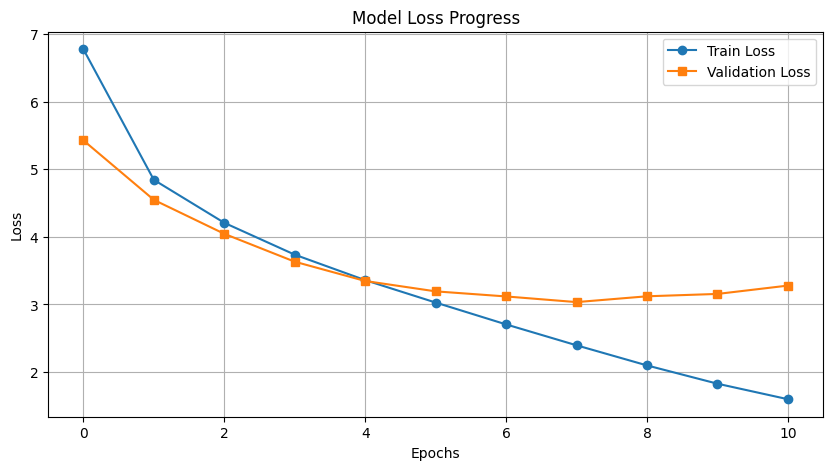

In [129]:
# 훈련 손실과 검증 손실 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [130]:
# 테스트해 볼 질문 문자열
question1 = "지루하다, 놀러가고 싶어."
question2 = "오늘 일찍 일어났더니 피곤하다."
question3 = "간만에 여자친구랑 데이트 하기로 했어."
question4 = "집에 있는다는 소리야."

print("# 예문")
print("1.", question1)
print("2.", question2)
print("3.", question3)
print("4.", question4)

print("-------------------------")

# Translations
print("# 제출")
print("1.", evaluate(question1, transformer, encoder_tokenizer, mecab))
print("2.", evaluate(question2, transformer, encoder_tokenizer, mecab))
print("3.", evaluate(question3, transformer, encoder_tokenizer, mecab))
print("4.", evaluate(question4, transformer, encoder_tokenizer, mecab))


# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있는다는 소리야.
-------------------------
# 제출
1. 다른 곳 을 찾아보 세요 .
2. 요즘 바쁜가 봐요 .
3. 좋 은 마무리 하 세요 .
4. 오늘 은 항상 막히 는 게 좋 죠 .
